# 딥러닝실습 중간고사   

제출자: 24011917 이지현   
제출일: 2026-04-18

**목표: 실습모델의 성능을 넘기는 더 가벼운 모델 구현**   
사용 모델: EfficientNet-B0   
선정 근거: AlexNet은 약 57M의 파라미터를 가지지만 위 모델은 약 4M 내외의 파라미터로 구성되여 훨씬 가벼운 모델이다. 하지만 ImageNet 데이터셋에서 성능이 입증되었으며 데이터가 적은 상황에서 전이 학습을 통한 높은 성능을 기대할 수 있어 해당 모델을 선정했다. 

# Part 1. 셋업

## 1-1. 라이브러리 설치

In [46]:
import os
import random
import glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import seaborn as sns
import matplotlib.ticker as ticker

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

import numpy as np


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


from facenet_pytorch import MTCNN

# 한글 폰트
plt.rcParams['font.family'] = 'malgun gothic'
plt.rcParams['axes.unicode_minus'] = False

print('torch:', torch.__version__)
print('CUDA :', torch.cuda.is_available())

torch: 2.11.0+cu128
CUDA : True


## 1-2. 시드 고정 + device + 경로

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

#torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True
#torch.use_deterministic_algorithms(True, warn_only=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 경로
ROOT_PATH    = r'C:\Users\user\Documents\50.2026\53.DL_실습\mid_test_image\raw_data'
IMAGE_FOLDER = os.path.join(ROOT_PATH, 'Video', 'Images')
LABEL_PATH   = os.path.join(ROOT_PATH, 'mosi_audio_metadata.csv')

print(f'Seed fixed: {SEED}')
print(f'device: {device}')
print(f'IMAGE_FOLDER: {IMAGE_FOLDER}')

Seed fixed: 42
device: cuda
IMAGE_FOLDER: C:\Users\user\Documents\50.2026\53.DL_실습\mid_test_image\raw_data\Video\Images


## 1-3. 라벨 로드

In [4]:
label_df = pd.read_csv(LABEL_PATH)

# 긍정:1, 부정:0
label_dict = {}
for _, row in label_df.iterrows():
    key = os.path.splitext(row['file_name'])[0]
    label_dict[key] = row['sentiment']

print(f'라벨 수: {len(label_dict)}')

라벨 수: 2199


In [5]:
print(label_df.columns.tolist())
print(label_df.head())
print('\nsentiment 값 분포:')
print(label_df['sentiment'].value_counts())
print('\nsentiment dtype:', label_df['sentiment'].dtype)


['file_name', 'audio_id', 'seg_idx', 'start_time', 'end_time', 'sentiment']
           file_name     audio_id  seg_idx  start_time   end_time  sentiment
0  03bSnISJMiM_1.wav  03bSnISJMiM        1   51.904533  55.945350       2.40
1  03bSnISJMiM_2.wav  03bSnISJMiM        2   56.045124  66.780720      -0.80
2  03bSnISJMiM_3.wav  03bSnISJMiM        3   66.780720  68.736280      -1.00
3  03bSnISJMiM_4.wav  03bSnISJMiM        4   68.736280  70.542175      -1.75
4  03bSnISJMiM_5.wav  03bSnISJMiM        5   70.542175  71.699550       0.00

sentiment 값 분포:
sentiment
 2.000000    120
-1.000000    110
-2.000000    103
 0.000000     96
 2.200000     94
 1.800000     94
 1.400000     92
-1.600000     91
 1.600000     90
-1.400000     79
 0.800000     77
-1.800000     72
-1.200000     71
-0.400000     69
-0.800000     68
 1.200000     68
 0.600000     63
 0.400000     62
 1.000000     62
 0.200000     61
-2.200000     61
-0.200000     55
-0.600000     55
 2.400000     54
 2.600000     44
-2.400000 

# Part 2. 데이터 전처리   

## 2-1. 데이터셋 가져오기

이미지 파일 수: 2199


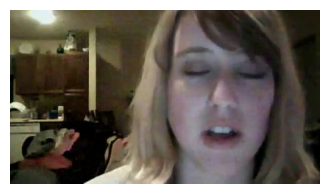

In [6]:
all_files = [f for f in os.listdir(IMAGE_FOLDER) if f.endswith(('.jpg'))]
print(f"이미지 파일 수: {len(all_files)}")

sample_path = os.path.join(IMAGE_FOLDER, all_files[0])
img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

## 2-2. 전처리   
1. face_crop : 얼굴만 집중 학습   
2. pad_img : 얼굴 이외의 여백을 주어 추후 transform에서 얼굴이 잘리지 않도록 조정   
3. denoise : 노이즈 감소   
4. sharpen : 샤프닝으로 이미지를 선명하게

In [7]:
def get_label(fname):
    # 파일명으로 라벨 가져오기 (긍정:1, 부정:0)
    name_key = os.path.splitext(fname)[0]
    if name_key in label_dict:
        return 1 if label_dict[name_key] >= 0 else 0
    return None

def load_image(path):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb

def face_crop(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        return img[y:y+h, x:x+w]
    return img

def pad_img(img, target_size=(224, 224)):
    h, w = img.shape[:2]
    target_w, target_h = target_size
    
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)
    
    resized = cv2.resize(img, (new_w, new_h))
    
    pad_top = (target_h - new_h) // 2
    pad_bottom = target_h - new_h - pad_top
    pad_left = (target_w - new_w) // 2
    pad_right = target_w - new_w - pad_left
    
    padded = cv2.copyMakeBorder(
        resized, pad_top, pad_bottom, pad_left, pad_right,
        borderType=cv2.BORDER_CONSTANT, value=(0, 0, 0)
    )
    return padded

def denoise_img(img):
    return cv2.boxFilter(img, -1, (3, 3))

def sharpen_img(img):
    kernel = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ])
    return cv2.filter2D(img, -1, kernel)

def normalize_img(img):
    return img.astype(np.float32) / 255.0

def build_dataset(pipeline_fn, files, img_folder):
    images, labels = [], []
    for fname in files:
        label = get_label(fname)
        if label is None:
            continue
        result = pipeline_fn(os.path.join(img_folder, fname))
        if result is not None:
            images.append(result)
            labels.append(label)
    return images, labels

def pipeline_D(path):
    img = load_image(path)
    if img is None:
        return None
    img = face_crop(img)
    img = pad_img(img)
    img = denoise_img(img)
    img = sharpen_img(img)
    #img = normalize_img(img) # 모델에서 ToTensor()로 0-1 정규화하므로 여기서는 생략
    return img

images, labels = build_dataset(pipeline_D, all_files, IMAGE_FOLDER)

print(f"이미지 수: {len(images)}")
print(f"라벨 수: {len(labels)}")
print(images[0].shape)

이미지 수: 2199
라벨 수: 2199
(224, 224, 3)


## 2-3. 데이터 증강   
데이터가 2천장밖에 없기 때문에 여러 방법으로 증강하였다. train만 증강하고, test는 원본으로 변형하지 않는다.

In [ ]:
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5), # 좌우 반전
    transforms.RandomRotation(degrees=15), # 회전
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2), # 색상 변화
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), # 이동
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # ImageNet 평균과 표준편차로 정규화
                         std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class ImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images      # (N, 224, 224, 3) uint8 numpy
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [ ]:
X = np.array(images)          
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_dataset = ImageDataset(X_train, y_train_t, transform=train_transforms)
test_dataset  = ImageDataset(X_test,  y_test_t,  transform=test_transforms)

print(f"훈련 샘플 수: {len(train_dataset)}")
print(f"테스트 샘플 수: {len(test_dataset)}")

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=train_generator, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train 배치 수: {len(train_loader)}")
print(f"Test 배치 수: {len(test_loader)}")

훈련 샘플 수: 1759
테스트 샘플 수: 440


# Part 3. 모델 정의

## 3-1. EfficientNet-B0 fine-tuning

- defalut_2의 AlexNet fine-tuning과 동일한 방식
- pretrained 가중치 로드 → 마지막 FC 레이어만 교체 → 전체 학습
- EfficientNet-B0은 AlexNet(57M)보다 파라미터가 적으면서 성능은 더 높음


In [110]:
# pretrained 가중치 로드
e_model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# 마지막 레이어 교체 (2클래스 분류)
in_features = e_model.classifier[1].in_features
e_model.classifier[1] = nn.Linear(in_features, 2)

e_model = e_model.to(device)

# 파라미터 수 확인
total_params = sum(p.numel() for p in e_model.parameters())
print(f'EfficientNet-B0 파라미터 수: {total_params:,}')


EfficientNet-B0 파라미터 수: 4,010,110


## 3-2. 중간 확인을 위한 시각화 코드 (학습 곡선)

In [53]:
def plot_training_results(train_losses, train_accs, num_epochs, test_acc=None,
                          test_losses=None, test_accs=None, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, num_epochs + 1)

    axes[0].plot(epochs, train_losses, 'b-', label='Train Loss')
    if test_losses:
        axes[0].plot(epochs, test_losses, 'g-', label='Test Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} Training Loss' if title else 'Training Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, train_accs, 'r-', label='Train Acc')
    if test_accs:
        axes[1].plot(epochs, test_accs, 'k-', label='Test Acc')
    elif test_acc is not None:
        axes[1].axhline(y=test_acc, color='g', linestyle='--', label=f'Test Acc: {test_acc:.1f}%')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{title} Training Accuracy' if title else 'Training Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def plot_prediction_samples(model, X_test_t, X_test, y_test, device,
                            normalize_fn=None, title="Prediction Samples",
                            label_names=None, sample_count=8):
    if label_names is None:
        label_names = ["Negative", "Positive"]
    model.eval()
    sample_X = X_test_t[:sample_count].to(device)
    sample_y = y_test[:sample_count]
    with torch.no_grad():
        inp = normalize_fn(sample_X) if normalize_fn else sample_X
        sample_out = model(inp)
        _, sample_pred = torch.max(sample_out, 1)
        sample_pred = sample_pred.cpu().numpy()
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flatten()):
        img_show = X_test[i].transpose(1, 2, 0)
        ax.imshow(img_show)
        true_label = label_names[sample_y[i]]
        pred_label = label_names[sample_pred[i]]
        color = 'green' if sample_y[i] == sample_pred[i] else 'red'
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=11)
        ax.axis("off")
    plt.suptitle(f"{title} (Green=Correct, Red=Wrong)", fontsize=14)
    plt.tight_layout()
    plt.show()


# Part 4. 학습

## 4-1. train_model 함수

In [ ]:
def train_model(model, train_loader, criterion, optimizer, num_epochs, device):
    train_loss_list = []
    train_acc_list  = []

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        correct      = 0
        total        = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # print("images.device:", images.device)
            # print("model device:", next(model.parameters()).device)
            # print("GPU mem after batch:", torch.cuda.memory_allocated() / 1024**2, "MB")

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            correct      += (predicted == labels).sum().item()
            total        += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc  = correct / total

        train_loss_list.append(epoch_loss)
        train_acc_list.append(epoch_acc)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

    return train_loss_list, train_acc_list, 


## 4-2. evaluate_model 함수

In [18]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct      = 0
    total        = 0
    all_preds    = []
    all_labels   = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            correct      += (predicted == labels).sum().item()
            total        += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc  = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels


## 4-3. 학습 실행    

탐색할 파라미터:
- **학습률 (lr)**: 1e-3 / 1e-4 / 1e-5
- **에포크 수**: 5 / 10 / 20
- **옵티마이저**: Adam / SGD

총 24가지 조합을 순차 실행하여 Test Accuracy 기준 최적 파라미터를 찾는다.

In [ ]:
from itertools import product

LR_LIST        = [1e-3, 1e-4, 1e-5]
EPOCH_LIST     = [5, 10, 15, 20]
OPTIMIZER_LIST = ['Adam', 'SGD']

# 모든 조합 생성
grid_configs = [
    {'lr': lr, 'num_epochs': ep, 'optimizer': opt}
    for lr, ep, opt in product(LR_LIST, EPOCH_LIST, OPTIMIZER_LIST)
]

print(f'총 실험 수: {len(grid_configs)}')
for i, cfg in enumerate(grid_configs):
    print(f'  [{i+1:02d}] {cfg}')

총 실험 수: 24
  [01] {'lr': 0.001, 'num_epochs': 5, 'optimizer': 'Adam'}
  [02] {'lr': 0.001, 'num_epochs': 5, 'optimizer': 'SGD'}
  [03] {'lr': 0.001, 'num_epochs': 10, 'optimizer': 'Adam'}
  [04] {'lr': 0.001, 'num_epochs': 10, 'optimizer': 'SGD'}
  [05] {'lr': 0.001, 'num_epochs': 15, 'optimizer': 'Adam'}
  [06] {'lr': 0.001, 'num_epochs': 15, 'optimizer': 'SGD'}
  [07] {'lr': 0.001, 'num_epochs': 20, 'optimizer': 'Adam'}
  [08] {'lr': 0.001, 'num_epochs': 20, 'optimizer': 'SGD'}
  [09] {'lr': 0.0001, 'num_epochs': 5, 'optimizer': 'Adam'}
  [10] {'lr': 0.0001, 'num_epochs': 5, 'optimizer': 'SGD'}
  [11] {'lr': 0.0001, 'num_epochs': 10, 'optimizer': 'Adam'}
  [12] {'lr': 0.0001, 'num_epochs': 10, 'optimizer': 'SGD'}
  [13] {'lr': 0.0001, 'num_epochs': 15, 'optimizer': 'Adam'}
  [14] {'lr': 0.0001, 'num_epochs': 15, 'optimizer': 'SGD'}
  [15] {'lr': 0.0001, 'num_epochs': 20, 'optimizer': 'Adam'}
  [16] {'lr': 0.0001, 'num_epochs': 20, 'optimizer': 'SGD'}
  [17] {'lr': 1e-05, 'num_epochs'

In [ ]:
import time
import copy

def build_model():
    #매 실험마다 동일한 pretrained 가중치로 초기화.
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_feat = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_feat, 2)
    return m.to(device)

def build_optimizer(model, opt_name, lr):
    if opt_name == 'Adam':
        return optim.Adam(model.parameters(), lr=lr)
    elif opt_name == 'SGD':
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    raise ValueError(f'Unknown optimizer: {opt_name}')


grid_results = []   # 결과 누적 리스트
criterion    = nn.CrossEntropyLoss()

for i, cfg in enumerate(grid_configs):
    lr        = cfg['lr']
    num_ep    = cfg['num_epochs']
    opt_name  = cfg['optimizer']

    print(f'\n[{i+1}/{len(grid_configs)}] lr={lr}  epochs={num_ep}  optimizer={opt_name}')
    print('-' * 50)

    # 모델 & 옵티마이저 초기화
    exp_model = build_model()
    exp_optim = build_optimizer(exp_model, opt_name, lr)

    t0 = time.time()

    # 학습
    exp_train_loss, exp_train_acc = train_model(
        exp_model, train_loader, criterion, exp_optim, num_ep, device
    )

    # 평가
    test_loss_e, test_acc_e, preds_e, labels_e = evaluate_model(
        exp_model, test_loader, criterion, device
    )

    elapsed = time.time() - t0
    f1 = f1_score(labels_e, preds_e, average='weighted')

    print(f'  → Test Acc: {test_acc_e:.4f}  F1: {f1:.4f}  ({elapsed:.0f}s)')

    grid_results.append({
        'optimizer'  : opt_name,
        'lr'         : lr,
        'num_epochs' : num_ep,
        'test_acc'   : round(test_acc_e, 4),
        'f1_score'   : round(f1, 4),
        'final_train_acc': round(exp_train_acc[-1], 4),
        'elapsed_sec': round(elapsed, 1),
    })

    # 메모리 정리
    del exp_model
    torch.cuda.empty_cache()

print('\n=== 전체 실험 완료 ===')


[1/24] lr=0.001  epochs=5  optimizer=Adam
--------------------------------------------------
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 128.3056640625 MB
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 183.86181640625 MB
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 183.76806640625 MB
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 183.86181640625 MB
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 183.86181640625 MB
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 183.86181640625 MB
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 183.86181640625 MB
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 183.86181640625 MB
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 183.86181640625 MB
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 183.86181640625 MB
images.device: cuda:0
model device: cuda:0
GPU mem after batch: 183.861816406

In [21]:
results_df = pd.DataFrame(grid_results).sort_values('test_acc', ascending=False).reset_index(drop=True)
results_df.index += 1  

print('=== 실험 결과 (Test Accuracy 내림차순) ===')
print(results_df.to_string())

best = results_df.iloc[0]
print(f'\n★ 최적 파라미터 ★')
print(f'  optimizer : {best.optimizer}')
print(f'  lr        : {best.lr}')
print(f'  epochs    : {int(best.num_epochs)}')
print(f'  test_acc  : {best.test_acc:.4f}')
print(f'  f1_score  : {best.f1_score:.4f}')

results_df.to_csv('experiment_results.csv', index=False)

=== 실험 결과 (Test Accuracy 내림차순) ===
   optimizer       lr  num_epochs  test_acc  f1_score  final_train_acc  elapsed_sec
1       Adam  0.00010          10    0.6841    0.6839           0.7641        135.3
2       Adam  0.00100          20    0.6773    0.6760           0.8312        278.4
3       Adam  0.00010          15    0.6614    0.6577           0.8357        210.5
4       Adam  0.00010           5    0.6614    0.6580           0.6976         69.5
5       Adam  0.00010          20    0.6500    0.6504           0.8937        278.5
6       Adam  0.00100          10    0.6318    0.6306           0.7499        136.2
7       Adam  0.00100           5    0.6205    0.5898           0.6987        173.7
8       Adam  0.00100          15    0.6182    0.6179           0.7897        208.9
9        SGD  0.00100          15    0.6159    0.6104           0.6674        214.1
10      Adam  0.00001          10    0.6023    0.5807           0.6111        138.8
11      Adam  0.00001          20    0.60

In [ ]:
# 실험에서 최적화된 모델로 학습 (실험을 돌렸으면 돌리지 않아도 됨!)

criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(e_model.parameters(), lr=1e-4)
num_epochs = 10

print('=== 학습 시작 ===')
train_loss_list, train_acc_list = train_model(
    e_model, train_loader, criterion, optimizer, num_epochs, device
)

print('\n=== 테스트 평가 ===')
test_loss, test_acc, test_preds, test_labels = evaluate_model(
    e_model, test_loader, criterion, device
)
print(f'Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.4f}')

=== 학습 시작 ===
Epoch [5/10]  Loss: 0.6911  Acc: 53.5%
Epoch [10/10]  Loss: 0.6909  Acc: 53.5%
학습 완료!

=== 테스트 평가 ===
Test Loss: 0.6908  Test Acc: 0.5341


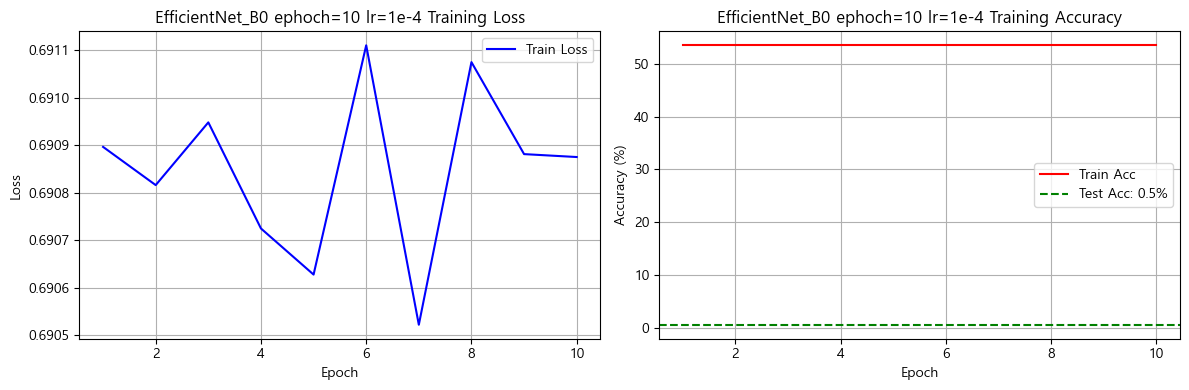

In [56]:
plot_training_results(
    train_loss_list, train_acc_list, num_epochs,
    test_acc=test_acc, title="EfficientNet_B0 ephoch=10 lr=1e-4"
)

In [132]:
from sklearn.metrics import confusion_matrix, classification_report

# e_model로 test 예측
e_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = e_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix 출력
cm = confusion_matrix(all_labels, all_preds)
print("=== Confusion Matrix ===")
print(f"                예측: Negative  예측: Positive")
print(f"실제: Negative      {cm[0][0]}            {cm[0][1]}")
print(f"실제: Positive      {cm[1][0]}            {cm[1][1]}")

# 정확도·F1 함께 출력
print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds,
                             target_names=['Negative', 'Positive']))

=== Confusion Matrix ===
                예측: Negative  예측: Positive
실제: Negative      115            90
실제: Positive      145            90

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.44      0.56      0.49       205
    Positive       0.50      0.38      0.43       235

    accuracy                           0.47       440
   macro avg       0.47      0.47      0.46       440
weighted avg       0.47      0.47      0.46       440



## 4-4. 베이스 모델 학습   
비교군인 베이스 모델 학습, Alexnet 보다 가벼운 CNN class도 만들었다.

In [89]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2): #분류
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)  
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)     
        self.drop1 = nn.Dropout2d(p=0.1)      # 별도로 dropout 추가하여 과적합 방지               
        
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(p=0.2)                     
        
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)    
        self.drop3 = nn.Dropout2d(p=0.25)                     
        
        self.flatten = nn.Flatten() #MLP에 넣을 수 있게 쫙 펴서 연결함
        self.fc1 = nn.Linear(64 * 28 * 28, 128) #완전 연결층, 64채널, 28x28 크기 -> 128차원으로 축소
        self.relu_fc = nn.ReLU() #활성화 함수
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes) #최종 출력층, 128차원 -> 클래스 수(2)로 축소
    
    def forward(self, x):
        x = self.drop1(self.pool1(self.relu1(self.conv1(x))))
        x = self.drop2(self.pool2(self.relu2(self.conv2(x))))
        x = self.drop3(self.pool3(self.relu3(self.conv3(x))))
        x = self.flatten(x)
        x = self.dropout(self.relu_fc(self.fc1(x)))
        x = self.fc2(x)
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=2).to(device)

In [90]:
def train_model(model, train_loader, criterion, 
                optimizer, num_epochs, device, 
                normalize_fn=None):
    train_losses = []
    train_accs = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            if normalize_fn:
                batch_X = normalize_fn(batch_X)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = correct / total * 100
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.1f}%")

    print("학습 완료!")
    return train_losses, train_accs

In [91]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 20

In [93]:
train_loss_max, train_acc_max = train_model(
    model, train_loader, criterion, optimizer, num_epochs, device
)

Epoch [5/20]  Loss: 0.6891  Acc: 54.4%
Epoch [10/20]  Loss: 0.6833  Acc: 54.6%
Epoch [15/20]  Loss: 0.6801  Acc: 56.6%
Epoch [20/20]  Loss: 0.6768  Acc: 57.2%
학습 완료!


In [94]:
test_loss_max, test_acc_max, test_preds_max, test_labels_max = evaluate_model(model, test_loader, criterion, device)

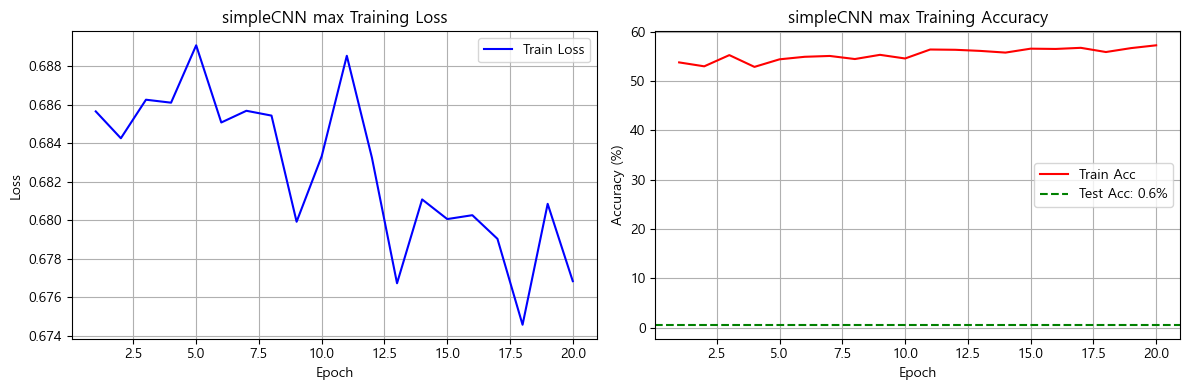

In [95]:
plot_training_results(
    train_loss_max, train_acc_max, 20,
    test_acc=test_acc_max, title="simpleCNN max"
)

In [119]:
class SimpleCNN_AVG(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN_AVG, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)   
        self.relu1 = nn.ReLU()
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)  
        self.relu2 = nn.ReLU()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)  
        self.relu3 = nn.ReLU()
        self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        
        self.flatten = nn.Flatten()                                
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.relu_fc = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu_fc(self.fc1(x)))
        x = self.fc2(x)
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_AVG = SimpleCNN_AVG(num_classes=2).to(device)

In [120]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_AVG.parameters(), lr=0.001)
num_epochs = 20

In [121]:
train_losses_avg, train_accs_avg = train_model(
    model_AVG, train_loader, criterion, optimizer, num_epochs, device
)


Epoch [5/20]  Loss: 0.6812  Acc: 56.5%
Epoch [10/20]  Loss: 0.6702  Acc: 57.4%
Epoch [15/20]  Loss: 0.6608  Acc: 59.4%
Epoch [20/20]  Loss: 0.6493  Acc: 61.1%
학습 완료!


In [124]:
test_loss_avg, test_acc_avg, test_preds_avg, test_labels_avg = evaluate_model(model_AVG, test_loader, criterion, device)

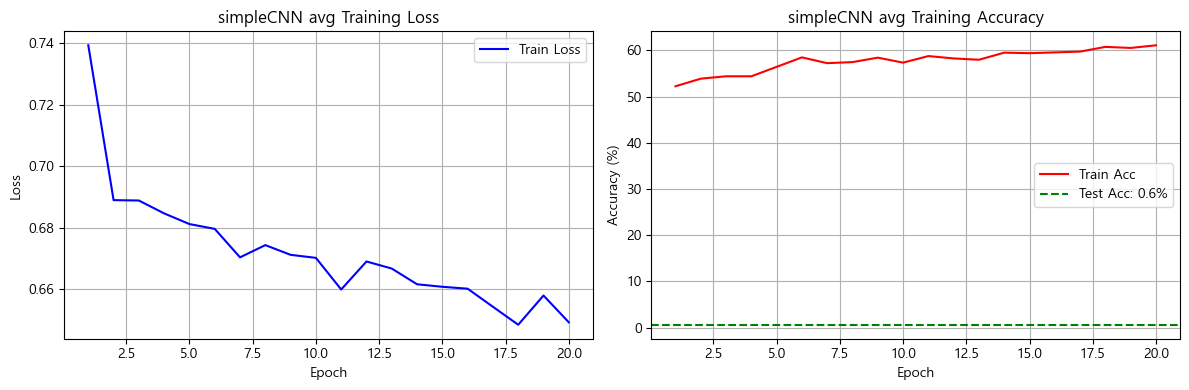

In [125]:
plot_training_results(
    train_losses_avg, train_accs_avg, 20,
    test_acc=test_acc_avg, title="simpleCNN avg"
)

In [101]:
from torchvision.models import alexnet, AlexNet_Weights

In [102]:
alexnet_weights = AlexNet_Weights.DEFAULT
alexnet_mean = torch.tensor([0.485, 0.456, 0.406], 
                            dtype=torch.float32).view(1, 3, 1, 1)
alexnet_std = torch.tensor([0.229, 0.224, 0.225], 
                           dtype=torch.float32).view(1, 3, 1, 1)
criterion_alexnet = nn.CrossEntropyLoss()
label_names = ["Negative", "Positive"]

alexnet_model = alexnet(weights=alexnet_weights)

in_features = alexnet_model.classifier[6].in_features
alexnet_model.classifier[6] = nn.Linear(in_features, 2)
alexnet_model = alexnet_model.to(device)
alexnet_initial_state = {k: v.detach().cpu().clone() for k, v in alexnet_model.state_dict().items()}             

In [103]:
def normalize_for_alexnet(batch_X):
    mean = alexnet_mean.to(batch_X.device)
    std = alexnet_std.to(batch_X.device)
    return (batch_X - mean) / std

optimizer_alexnet = optim.Adam(alexnet_model.parameters(), lr=1e-4)
alexnet_num_epochs = 25

alexnet_train_losses, alexnet_train_accs = train_model(
    alexnet_model, train_loader, criterion_alexnet, optimizer_alexnet, alexnet_num_epochs, device,
    normalize_fn=normalize_for_alexnet
)

Epoch [5/25]  Loss: 0.6382  Acc: 62.3%
Epoch [10/25]  Loss: 0.6092  Acc: 65.8%
Epoch [15/25]  Loss: 0.5873  Acc: 67.5%
Epoch [20/25]  Loss: 0.5641  Acc: 70.3%
Epoch [25/25]  Loss: 0.5213  Acc: 74.5%
학습 완료!


In [104]:
test_loss3, test_acc3, test_preds3, test_labels3 = evaluate_model(alexnet_model, test_loader, criterion, device)

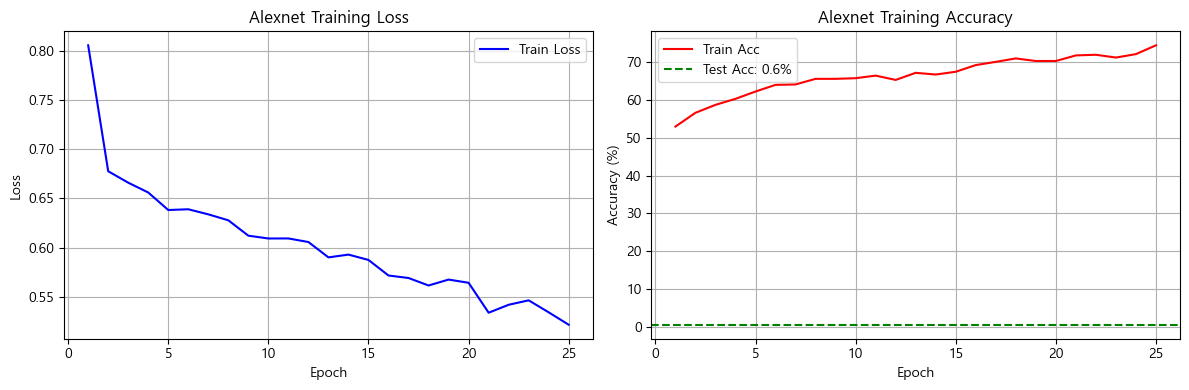

In [106]:
plot_training_results(
    alexnet_train_losses, alexnet_train_accs, 25,
    test_acc=test_acc3, title="Alexnet"
)

# Part 5. 시각화

## 5-1. 모델별 파라미터 수 비교

In [115]:
def count_params(model, model_name="Model"):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{model_name}]")
    print(f"  전체 파라미터 수:     {total:,}")
    print(f"  학습 가능 파라미터 수: {trainable:,}")
    print()

    return total

max_p = count_params(model, "SimpleCNN (MaxPool)")
avg_p = count_params(model_AVG, "SimpleCNN_AVG (AvgPool)")
alexnet_p = count_params(alexnet_model, "AlexNet")
efficientnet_p = count_params(e_model, "EfficientNet_B0")

[SimpleCNN (MaxPool)]
  전체 파라미터 수:     6,446,498
  학습 가능 파라미터 수: 6,446,498

[SimpleCNN_AVG (AvgPool)]
  전체 파라미터 수:     6,446,498
  학습 가능 파라미터 수: 6,446,498

[AlexNet]
  전체 파라미터 수:     57,012,034
  학습 가능 파라미터 수: 57,012,034

[EfficientNet_B0]
  전체 파라미터 수:     4,010,110
  학습 가능 파라미터 수: 4,010,110



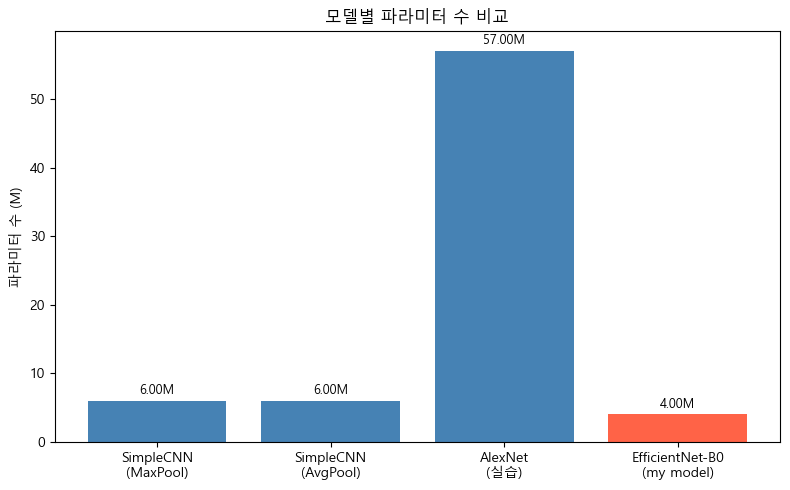

viz_01_params.png 저장 완료


In [ ]:
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 모델 파라미터 수 
param_names  = ['SimpleCNN\n(MaxPool)', 'SimpleCNN\n(AvgPool)', 'AlexNet\n(실습)', 'EfficientNet-B0\n(my model)']
param_counts = [max_p//1e6, avg_p//1e6, alexnet_p//1e6, efficientnet_p//1e6]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(param_names, param_counts, color=['steelblue', 'steelblue', 'steelblue', 'tomato'])
ax.set_ylabel('파라미터 수 (M)')
ax.set_title('모델별 파라미터 수 비교')
for bar, val in zip(bars, param_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('viz_01_params.png', dpi=150)
plt.show()
print('viz_01_params.png 저장 완료')


## 5-2. Test Accuracy 비교 (baseline vs my model)

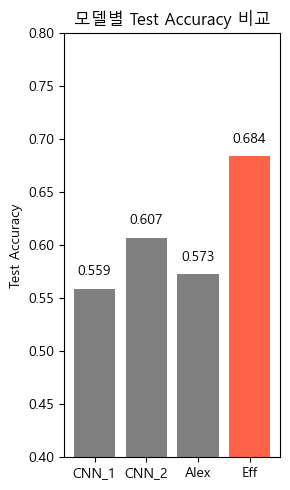

viz_02_accuracy_compare.png 저장 완료


In [131]:
result_names = ['CNN_1', 'CNN_2', 'Alex', 'Eff']
result_accs  = [test_acc_max, test_acc_avg, test_acc3, best.test_acc]

colors = ['grey', 'grey', 'grey', 'tomato']

fig, ax = plt.subplots(figsize=(3, 5))
bars = ax.bar(result_names, result_accs, color=colors)
ax.set_ylim(0.4, 0.8)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.set_ylabel('Test Accuracy')
ax.set_title('모델별 Test Accuracy 비교')
for bar, val in zip(bars, result_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('viz_02_accuracy_compare.png', dpi=150)
plt.show()
print('viz_02_accuracy_compare.png 저장 완료')


## 5-3. 연구 시각화

C:\Users\user\AppData\Local\Temp\ipykernel_29924\927095809.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.sort_values('test_acc', ascending=False), x='test_acc', y='config', palette='viridis',ax=axes[0])


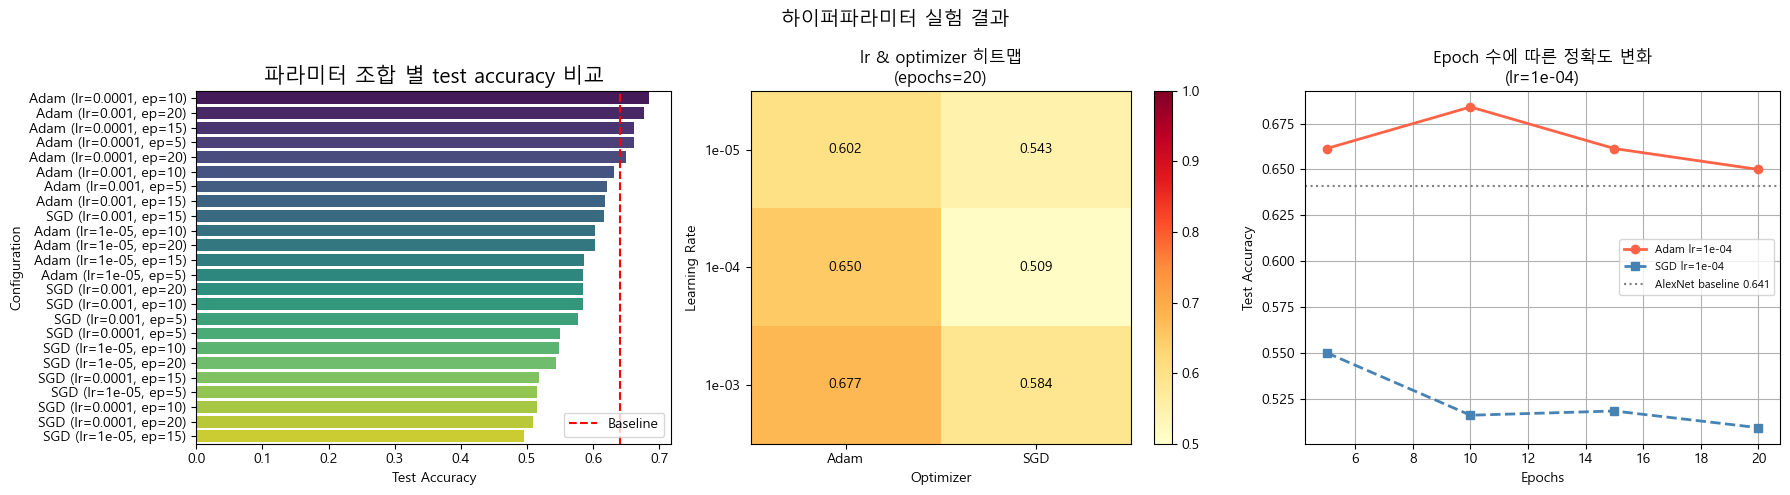

viz_05_grid_search.png 저장 완료


In [ ]:
df = pd.read_csv('experiment_results.csv')
df['config'] = df['optimizer'] + " (lr=" + df['lr'].astype(str) + ", ep=" + df['num_epochs'].astype(str) + ")"


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('하이퍼파라미터 실험 결과', fontsize=14)

# 그래프1. acc 비교
sns.barplot(data=df.sort_values('test_acc', ascending=False), x='test_acc', y='config', palette='viridis',ax=axes[0])
axes[0].axvline(0.641, color='red', linestyle='--', label='Baseline') # 기준선 추가
axes[0].set_title('파라미터 조합 별 test accuracy 비교', fontsize=15)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_ylabel('Configuration')
axes[0].legend()


#그래프2. lr + optimizer 히트맵
pivot_df = results_df[results_df['num_epochs'] == EPOCH_LIST[-1]].pivot_table(
    index='lr', columns='optimizer', values='test_acc'
)
im = axes[1].imshow(pivot_df.values, cmap='YlOrRd', aspect='auto', vmin=0.5, vmax=1.0)
axes[1].set_xticks(range(len(pivot_df.columns)))
axes[1].set_yticks(range(len(pivot_df.index)))
axes[1].set_xticklabels(pivot_df.columns)
axes[1].set_yticklabels([f'{v:.0e}' for v in pivot_df.index])
axes[1].set_xlabel('Optimizer')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title(f'lr & optimizer 히트맵\n(epochs={EPOCH_LIST[-1]})')
plt.colorbar(im, ax=axes[1])
for r in range(pivot_df.shape[0]):
    for c in range(pivot_df.shape[1]):
        val = pivot_df.values[r, c]
        axes[1].text(c, r, f'{val:.3f}', ha='center', va='center', fontsize=10,
                     color='black' if val < 0.75 else 'white')

# 그래프3. epochs 별 test acc
best_lr = best['lr']
df_epoch = results_df[
    (results_df['optimizer'] == 'Adam') & (results_df['lr'] == best_lr)
].sort_values('num_epochs')
axes[2].plot(df_epoch['num_epochs'], df_epoch['test_acc'],
             marker='o', color='tomato', linewidth=2, label=f'Adam lr={best_lr:.0e}')
# SGD 동일 lr도 함께 표시
df_sgd = results_df[
    (results_df['optimizer'] == 'SGD') & (results_df['lr'] == best_lr)
].sort_values('num_epochs')
axes[2].plot(df_sgd['num_epochs'], df_sgd['test_acc'],
             marker='s', color='steelblue', linewidth=2, linestyle='--',
             label=f'SGD lr={best_lr:.0e}')
axes[2].axhline(y=0.641, color='gray', linestyle=':', linewidth=1.5, label='AlexNet baseline 0.641')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_title(f'Epoch 수에 따른 정확도 변화\n(lr={best_lr:.0e})')
axes[2].legend(fontsize=8)
axes[2].grid(True)

plt.tight_layout()
plt.savefig('viz_03_grid_search.png', dpi=150)
plt.show()
print('viz_03_grid_search.png 저장 완료')

## 5-4. 데이터 증강 시각화   

결과 예시   
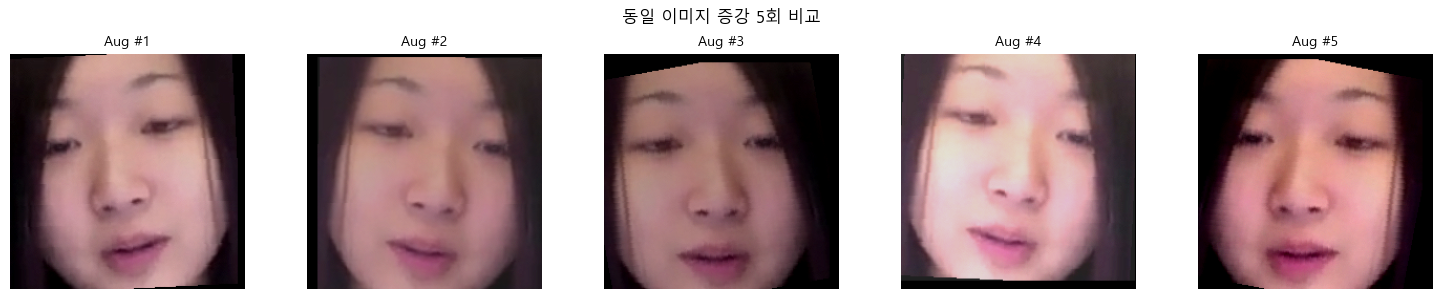

In [ ]:
# 동일 이미지에 증강 5번 적용 비교
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('동일 이미지 증강 5회 비교', fontsize=12)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i, ax in enumerate(axes):
    img, _ = train_dataset[10]   # 같은 index, 매번 다른 증강
    img_show = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img_show)
    ax.set_title(f'Aug #{i+1}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('viz_aug_comparison.png', dpi=150)
plt.show()